In [3]:
%matplotlib inline

import rclpy
from rclpy.node import Node
from nav_msgs.srv import GetMap
from nav_msgs.msg import OccupancyGrid

import numpy as np
import matplotlib.pyplot as plt

In [4]:
def getMap(timeout_sec: float = 5.0) -> OccupancyGrid:

    get_map = node.create_client(GetMap, '/map_server/map')

    if not get_map.wait_for_service(timeout_sec=timeout_sec):
        raise RuntimeError("/map_server/map service not available")

    req = GetMap.Request()

    future = get_map.call_async(req)

    rclpy.spin_until_future_complete(node, future, timeout_sec=timeout_sec)

    if not future.done() or future.result() is None:
        raise RuntimeError("GetMap call failed")

    return future.result().map

In [6]:
try:
    rclpy.init(args=None)
except:
    pass

node = Node('moro_maze_navigation')

recMap = getMap()

In [7]:
print(recMap.info.width)
print(recMap.info.height)
print(recMap.info.resolution)

27
27
0.16666699945926666


In [8]:
grid = np.array(recMap.data).reshape(
    recMap.info.height,
    recMap.info.width
)

print(grid.shape)

(27, 27)


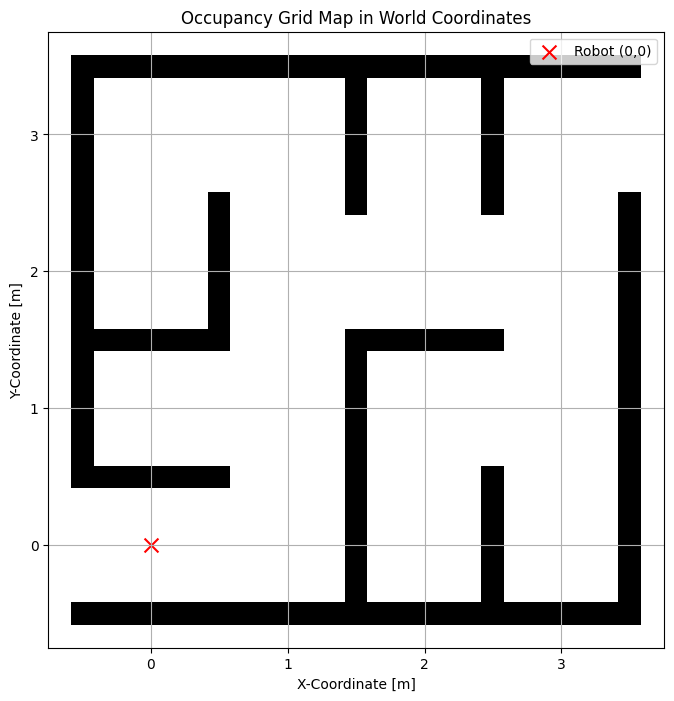

In [20]:
import matplotlib.pyplot as plt

resolution = recMap.info.resolution
origin_x = recMap.info.origin.position.x
origin_y = recMap.info.origin.position.y

width = recMap.info.width
height = recMap.info.height

plt.figure(figsize=(8,8))

plt.imshow(
    grid,
    cmap='gray_r',
    origin='lower',
    extent=[
        origin_x,
        origin_x + width * resolution,
        origin_y,
        origin_y + height * resolution
    ]
)

plt.scatter([0], [0], c='red', s=100, marker='x', label='Robot (0,0)')

plt.xlabel("X-Coordinate [m]")
plt.ylabel("Y-Coordinate [m]")

plt.title("Occupancy Grid Map in World Coordinates")

plt.legend()
plt.grid()

plt.show()

#여기까지 그냥 지도 불러오기 미터로 바꾸고 

In [22]:
wall_indices = np.argwhere(grid > 50) #벽 
free_indices = np.argwhere(grid == 0) #이동가능 

resolution = recMap.info.resolution #그리드 한칸 미터 

origin_x = recMap.info.origin.position.x
origin_y = recMap.info.origin.position.y

wall_x = wall_indices[:, 1] * resolution + origin_x + resolution / 2
wall_y = wall_indices[:, 0] * resolution + origin_y + resolution / 2

free_x = free_indices[:, 1] * resolution + origin_x + resolution / 2
free_y = free_indices[:, 0] * resolution + origin_y + resolution / 2

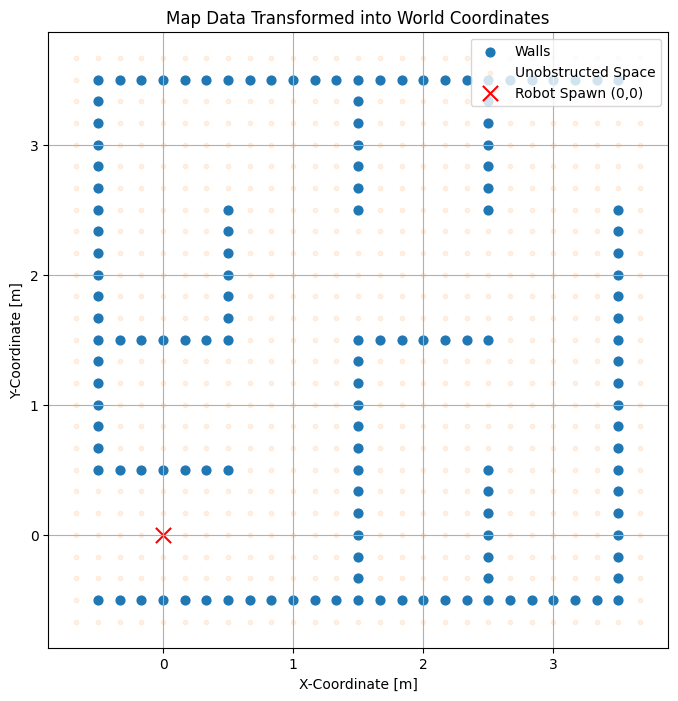

In [23]:
plt.figure(figsize=(8,8))

plt.scatter(
    wall_x,
    wall_y,
    s=40,
    label="Walls"
)

plt.scatter(
    free_x,
    free_y,
    s=10,
    alpha=0.1,
    label="Unobstructed Space"
)

plt.scatter(
    [0],
    [0],
    c='red',
    s=120,
    marker='x',
    label='Robot Spawn (0,0)'
)

plt.xlabel("X-Coordinate [m]")
plt.ylabel("Y-Coordinate [m]")

plt.title("Map Data Transformed into World Coordinates")

plt.legend()
plt.grid()
plt.axis("equal")

plt.show()
#벽들, 다닐수 있는 공간 그래프 

In [29]:
def toNodeName(row, col):
    return f"{row}.{col}"


def fromNodeName(name, recMap):
    row, col = name.split(".")
    row = int(row)
    col = int(col)
    x, y = map_to_world(row, col, recMap)
    return np.array([y, x])

In [30]:
def path_is_free(row1, col1, row2, col2, grid):
    if row1 == row2:
        start = min(col1, col2)
        end = max(col1, col2)

        for col in range(start, end + 1):
            if not is_free(row1, col, grid):
                return False

        return True

    elif col1 == col2:
        start = min(row1, row2)
        end = max(row1, row2)

        for row in range(start, end + 1):
            if not is_free(row, col1, grid):
                return False

        return True

    else:
        return False
#두 노드가, 같은 행 또은 열에 있고, 중간에 벽이 없을때 이동 가능 

In [35]:
def create_sparse_graph(grid):
    candidate_rows = [4, 10, 16, 22]
    candidate_cols = [4, 10, 16, 22]

    nodes = []

    for row in candidate_rows:
        for col in candidate_cols:
            if is_free(row, col, grid):
                nodes.append((row, col))

    node_set = set(nodes)
    edges = []

    # 오른쪽 방향 연결
    for row, col in nodes:
        for next_col in candidate_cols:
            if next_col <= col:
                continue

            if (row, next_col) not in node_set:
                continue

            if path_is_free(row, col, row, next_col, grid):
                edges.append({
                    "parent": toNodeName(row, col),
                    "child": toNodeName(row, next_col),
                    "cost": abs(next_col - col)
                })
                break

    # 위쪽 방향 연결
    for row, col in nodes:
        for next_row in candidate_rows:
            if next_row <= row:
                continue

            if (next_row, col) not in node_set:
                continue

            if path_is_free(row, col, next_row, col, grid):
                edges.append({
                    "parent": toNodeName(row, col),
                    "child": toNodeName(next_row, col),
                    "cost": abs(next_row - row)
                })
                break

    return nodes, edges
#너무 많으니까, 대표만 뽑아서 이동가능한 노드만 설정 

In [36]:
nodes, edges = create_sparse_graph(grid)

print(edges[:10])

[{'parent': '4.4', 'child': '4.10', 'cost': 6}, {'parent': '10.4', 'child': '10.10', 'cost': 6}, {'parent': '10.16', 'child': '10.22', 'cost': 6}, {'parent': '16.10', 'child': '16.16', 'cost': 6}, {'parent': '16.16', 'child': '16.22', 'cost': 6}, {'parent': '22.4', 'child': '22.10', 'cost': 6}, {'parent': '4.10', 'child': '10.10', 'cost': 6}, {'parent': '4.16', 'child': '10.16', 'cost': 6}, {'parent': '4.22', 'child': '10.22', 'cost': 6}, {'parent': '10.10', 'child': '16.10', 'cost': 6}]


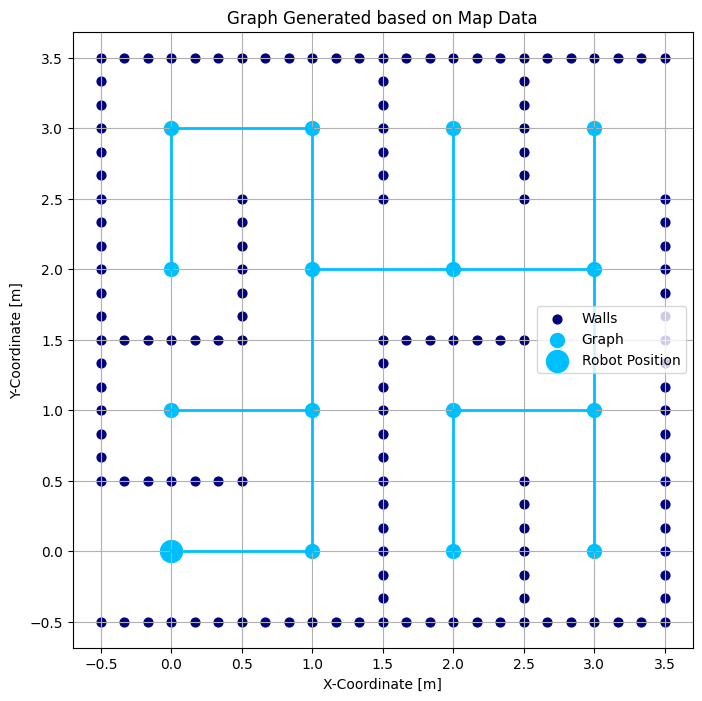

In [38]:
nodePositions = np.array(
    [fromNodeName(edge["parent"], recMap) for edge in edges] +
    [fromNodeName(edge["child"], recMap) for edge in edges]
)

nodePositions = np.unique(nodePositions, axis=0)

edgeLines = np.array([
    [
        fromNodeName(edge["parent"], recMap),
        fromNodeName(edge["child"], recMap)
    ]
    for edge in edges
])

plt.figure(figsize=(8,8))

plt.scatter(
    wall_x,
    wall_y,
    s=40,
    c='navy',
    label="Walls"
)

plt.scatter(
    nodePositions[:, 0],
    nodePositions[:, 1],
    s=100,
    c='deepskyblue',
    label="Graph"
)

plt.scatter(
    [0],
    [0],
    s=250,
    c='deepskyblue',
    label="Robot Position"
)

for line in edgeLines:
    x0, y0 = line[0]
    x1, y1 = line[1]

    plt.plot(
        [x0, x1],
        [y0, y1],
        color='deepskyblue',
        linewidth=2
    )

plt.xlabel("X-Coordinate [m]")
plt.ylabel("Y-Coordinate [m]")

plt.title("Graph Generated based on Map Data")

plt.legend()
plt.grid()
plt.axis("equal")

plt.show()
#위에서 뽑은 중간에 벽 없는 위치 노드들만 좌표로 변환해서 출력 

In [39]:
def getChildren(edges, node):
    children = []

    for edge in edges:
        if edge["parent"] == node:
            children.append(edge["child"])

        # 길은 양방향으로 이동 가능하다고 보기
        if edge["child"] == node:
            children.append(edge["parent"])

    return children
#현재 노드에서 갈 수 있는 노드 찾기 

def BFS(start, goal, edges):
    discoveredNodes = []
    visited = set()
    queue = [start]

    visited.add(start)

    while queue:
        current = queue.pop(0)

        if current == goal:
            return discoveredNodes

        children = getChildren(edges, current)

        for child in children:
            if child not in visited:
                visited.add(child)

                discoveredNodes.append({
                    "parent": current,
                    "child": child
                })

                queue.append(child)

    return discoveredNodes

def reconstruct_path(discoveredNodes, start, goal):
    path = [goal]
    current = goal

    while current != start:
        parent = None

        for edge in discoveredNodes:
            if edge["child"] == current:
                parent = edge["parent"]
                break

        if parent is None:
            raise RuntimeError("Path could not be reconstructed")

        path.append(parent)
        current = parent

    path.reverse()
    return path


In [40]:
start = "4.4"
goal = "22.22"

discoveredNodes = BFS(start, goal, edges)
path = reconstruct_path(discoveredNodes, start, goal)

print("Found Path:")
print(path)

Found Path:
['4.4', '4.10', '10.10', '16.10', '16.16', '16.22', '22.22']


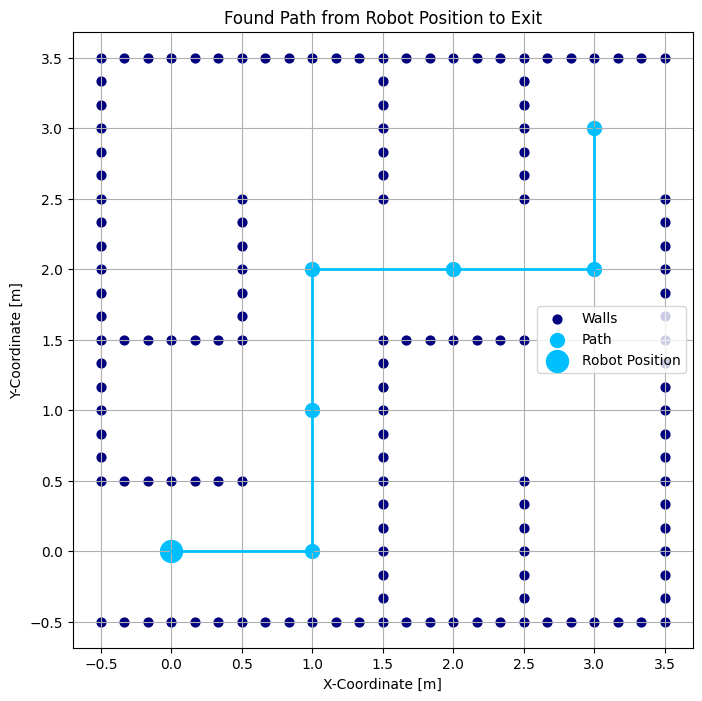

In [41]:
pathPositions = np.array([
    fromNodeName(n, recMap) for n in path
])

pathLines = np.array([
    [
        fromNodeName(path[i-1], recMap),
        fromNodeName(path[i], recMap)
    ]
    for i in range(1, len(path))
])

plt.figure(figsize=(8,8))

plt.scatter(wall_x, wall_y, s=40, c='navy', label="Walls")
plt.scatter(pathPositions[:, 0], pathPositions[:, 1], s=100, c='deepskyblue', label="Path")
plt.scatter([0], [0], s=250, c='deepskyblue', label="Robot Position")

for line in pathLines:
    x0, y0 = line[0]
    x1, y1 = line[1]
    plt.plot([x0, x1], [y0, y1], c='deepskyblue', linewidth=2)

plt.xlabel("X-Coordinate [m]")
plt.ylabel("Y-Coordinate [m]")
plt.title("Found Path from Robot Position to Exit")

plt.legend()
plt.grid()
plt.axis("equal")
plt.show()

In [42]:
def nearest_node(robot_position, nodes, recMap):

    robot_x, robot_y = robot_position

    min_distance = float("inf")
    nearest = None

    for row, col in nodes:

        node_x, node_y = map_to_world(row, col, recMap)

        distance = np.sqrt(
            (robot_x - node_x)**2 +
            (robot_y - node_y)**2
        )

        if distance < min_distance:
            min_distance = distance
            nearest = (row, col)

    return toNodeName(nearest[0], nearest[1])
#시작노드와 출구노드가 정해지지 않을때 

In [43]:
robot_position = (0.0, 0.0)

start = nearest_node(robot_position, nodes, recMap)

print("start node:", start)

start node: 4.4


In [45]:
def find_exit_node(nodes):

    best_node = None
    best_score = -1

    for row, col in nodes:

        score = row + col

        if score > best_score:
            best_score = score
            best_node = (row, col)

    return toNodeName(best_node[0], best_node[1])

goal = find_exit_node(nodes)

print("goal node:", goal)

goal node: 22.22


In [46]:
discoveredNodes = BFS(start, goal, edges)

path = reconstruct_path(
    discoveredNodes,
    start,
    goal
)

print("Found Path:")
print(path)

Found Path:
['4.4', '4.10', '10.10', '16.10', '16.16', '16.22', '22.22']


In [48]:
def path_to_world_coordinates(path, recMap):
    world_path = []

    for node_name in path:
        x, y = fromNodeName(node_name, recMap)
        world_path.append((x, y))

    return world_path
    #노드를 좌표계로 바꾸기 

In [49]:
world_path = path_to_world_coordinates(path, recMap)

print("World Path:")
for point in world_path:
    print(point)

World Path:
(np.float64(1.4975666999816895e-06), np.float64(1.4975666999816895e-06))
(np.float64(1.0000034943223), np.float64(1.4975666999816895e-06))
(np.float64(1.0000034943223), np.float64(1.0000034943223))
(np.float64(1.0000034943223), np.float64(2.0000054910779))
(np.float64(2.0000054910779), np.float64(2.0000054910779))
(np.float64(3.0000074878335), np.float64(2.0000054910779))
(np.float64(3.0000074878335), np.float64(3.0000074878335))


In [50]:
def add_theta_to_path(world_path):
    trajectory = []

    for i in range(len(world_path)):
        x, y = world_path[i]

        if i < len(world_path) - 1:
            next_x, next_y = world_path[i + 1]
            theta = np.arctan2(next_y - y, next_x - x)
        else:
            theta = trajectory[-1][2] if len(trajectory) > 0 else 0.0

        trajectory.append((x, y, theta))

    return trajectory
global_path = add_theta_to_path(world_path)

print("Global Path:")
for pose in global_path:
    print(pose)
    #좌표계에 방향각 추가해서 최종 path 만들기 

Global Path:
(np.float64(1.4975666999816895e-06), np.float64(1.4975666999816895e-06), np.float64(0.0))
(np.float64(1.0000034943223), np.float64(1.4975666999816895e-06), np.float64(1.5707963267948966))
(np.float64(1.0000034943223), np.float64(1.0000034943223), np.float64(1.5707963267948966))
(np.float64(1.0000034943223), np.float64(2.0000054910779), np.float64(0.0))
(np.float64(2.0000054910779), np.float64(2.0000054910779), np.float64(0.0))
(np.float64(3.0000074878335), np.float64(2.0000054910779), np.float64(1.5707963267948966))
(np.float64(3.0000074878335), np.float64(3.0000074878335), np.float64(1.5707963267948966))
